# Task 5 (Hudson Mercer)

### Visualizing the Gaussian Distribution of the Cleaned Data

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from astropy.table import Table 
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size = 12)

Average flux/brightness observed: 0.9986380117042404
Standard deviation for the flux: 0.00461364730607119


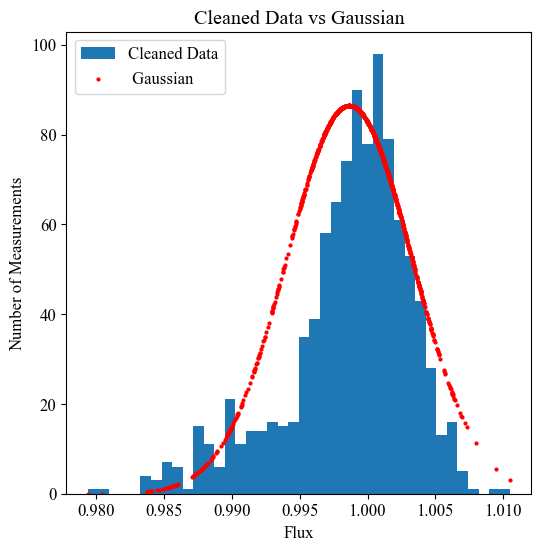

In [7]:
# finding the mean and standard deviation from the cleaned data 
mu = np.mean(clean_y)
std = np.std(clean_y)
print(f'Average flux/brightness observed: {mu}')
print(f'Standard deviation for the flux: {std}')

# creating a function to define a Gaussian 
def gaussian(x, mu, sigma):
    norm = 1/(np.sqrt(2*np.pi*sigma**2)) 

    exponential = np.exp((-1*(x -mu)**2/(2*sigma**2)))

    return norm*exponential

# Plotting the cleaned data as a histogram vs its Gaussian 
# I used plt.scatter rather than plt.plot b/c it represented the Gaussian shape better 
plt.figure(figsize = (6,6))
t = plt.hist(clean_y, bins = 40, label = 'Cleaned Data')
plt.scatter(clean_y, gaussian(clean_y, mu, std), c='r', label = ' Gaussian', s = 4)
plt.xlabel('Flux')
plt.ylabel('Number of Measurements')
plt.title('Cleaned Data vs Gaussian')
plt.legend()
plt.show()


### Creating the Outlier

In [8]:
# creating an outlier with a flux 10% brighter than the mean
outlier = mu*1.1
print(f'Flux of outlier that is 10% brighter than the mean: {outlier}')

# calculating n-sigma of a solar flare 10% brighter than the mean from the cleaned up data 
N_sigma = np.abs((outlier-mu)/std)
print(f'The outlier is a {N_sigma:4.3}-sigma event')

Flux of outlier that is 10% brighter than the mean: 1.0985018128746644
The outlier is a 21.6-sigma event


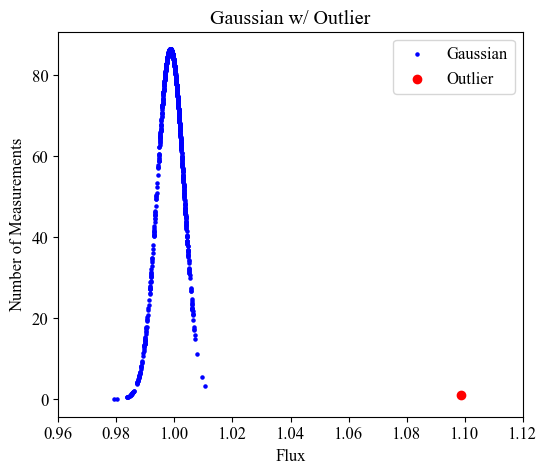

In [9]:
# replotting the Gaussian including the outlier 
plt.figure(figsize = (6,5))
plt.scatter(clean_y, gaussian(clean_y, mu, std), c='blue', s = 5, label = 'Gaussian')
plt.scatter(outlier, 1, c = 'r', label = 'Outlier')
plt.xlim(0.96, 1.12)
plt.xlabel('Flux')
plt.ylabel('Number of Measurements')
plt.title('Gaussian w/ Outlier')
plt.legend()
plt.show()

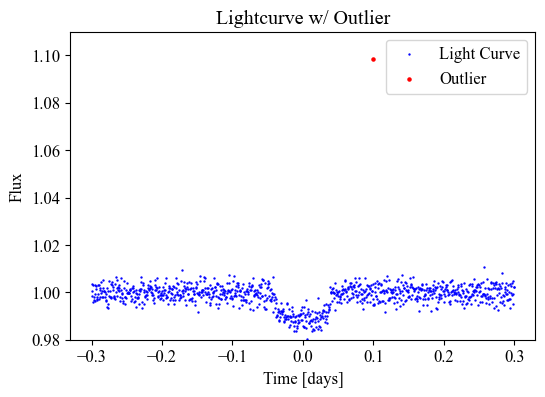

In [10]:
# assigning an arbitrary time (x-value) for the outlier NOT during transit
x_outlier = 0.1

# adding the outlier to the light curve (from Task 2) 
plt.figure(figsize = (6,4))
plt.scatter(x_data,clean_y, c = 'blue', s=0.5, label = 'Light Curve')
plt.scatter(x_outlier, outlier, c='r', s = 5, label = 'Outlier')
plt.ylim(0.98, 1.11)
plt.xlabel('Time [days]')
plt.ylabel('Flux')
plt.title('Lightcurve w/ Outlier')
plt.legend()
plt.show()

### Calculating the Statistical Significance of the Outlier 

0.9987377757413737
0.005587247989212821


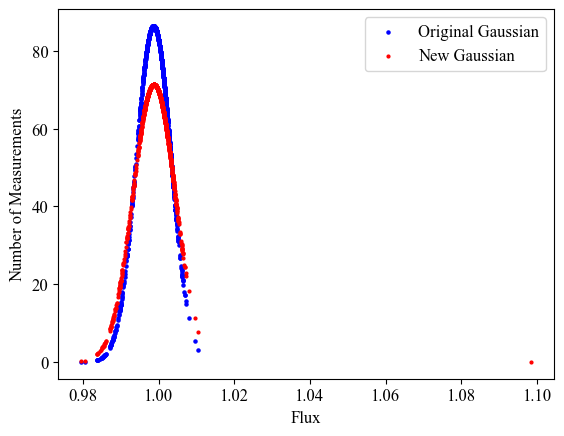

In [11]:
# trying the t-test and finding a p-value

# appending the outlier to the original cleaned data 
clean_y_new = np.append(clean_y, outlier)

# finding new values for mu and std that include the outlier
mu_outlier = np.mean(clean_y_new)
std_outlier = np.std(clean_y_new)
print(mu_outlier)
print(std_outlier)

# comparing the OG Gaussian with the new Gaussian (that includes the outlier) 
plt.scatter(clean_y, gaussian(clean_y, mu, std), c='blue', s = 5, label = 'Original Gaussian')
plt.scatter(clean_y_new, gaussian(clean_y_new, mu_outlier, std_outlier), c='r',s=4, label = 'New Gaussian')
plt.xlabel('Flux')
plt.ylabel('Number of Measurements')
plt.legend()

In [12]:
def p_value(x0, x1):
    '''
    x0: array giving measurements from OG cleaned data
    x1: array giving measurements from data with the added outlier 
    '''
    _, p = ttest_ind(x0, x1, equal_var = False)

    return p 

p = p_value(gaussian(clean_y, mu, std), gaussian(clean_y_new, mu_outlier, std_outlier))
print(f'The p-value for the null hypothesis of the outlier is {p*100:5.3}%')

# VERY small p-value indicates outlier is HIGHLY unlikely to be a random event 

The p-value for the null hypothesis of the outlier is 1.58e-11%


In [13]:

def solar_flare_prob(x, mean, s):
    '''
    inputs:
        x: solar flare magnitude 
        mean: expected mean from clean data (Gaussian)
        s: expected standard deviation of the Gaussian
    '''
  
    z = np.abs((x-mean)/s)

    prob_upper = 0.5*(1.0 + erf(z/np.sqrt(2)))
    prob_lower = 0.5*(1.0 + erf(-1*z/np.sqrt(2)))

    prob_inside = (prob_upper - prob_lower)

    prob_outside = 1.0 - prob_inside

    return prob_outside 



In [14]:
# declaring probability of outlier 
prob = solar_flare_prob(N_sigma, mu, std)
print(prob)
print(f'The probability of a solar flare of flux {outlier} is {prob*100:5.3}%.')

0.0
The probability of a solar flare of flux 1.0985018128746644 is   0.0%.


In [15]:
def chauvenet_criterion(clean_data, outlier):
    '''
    inputs:
        clean_data: array containing the original cleaned-up data set
        outlier: float, 10% brighter outlier along lightcurve where the transit isn't taking place

    returns: 
        keep: boolean, True if we can reject the null hypothesis, False if we can't reject the null hypothesis
    '''
    mu_prior = np.mean(clean_data)
    std_prior = np.std(clean_data)
    outlier_prob = solar_flare_prob(N_sigma, mu_prior, std_prior)

    N = len(clean_data) + 1
    product = N*outlier_prob

    # represents Chauvenet's Criterion 
    # if True, we CAN reject the null hypothesis
    if product < 0.5 and outlier_prob < 1/(2*N):
        reject = True
        return reject
    # if False, CANNOT reject the null hypothesis (
    else:
        reject = False
        return reject

In [17]:
# can we reject the null hypothesis?
chauvenet = chauvenet_criterion(clean_y, N_sigma)
print(f'With an outlier with flux {outlier}, is it true that we CAN reject the null hypothesis? Answer: {chauvenet}')

With an outlier with flux 1.0985018128746644, is it true that we CAN reject the null hypothesis? Answer: True
